In [1]:
import math

from PIL import Image
import requests
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
from torch import nn
from torchvision.models import resnet50
import torchvision.transforms as T

from transformers import DetrForObjectDetection, DetrImageProcessor
import torch

from torchvision.datasets import CocoDetection
from torch.utils.data import DataLoader

from torch.optim import AdamW

import os

from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [2]:
NUM_CLASSES = 72 + 1  

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    ignore_mismatched_sizes=True,
    num_labels=NUM_CLASSES
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

C:\Users\menci\anaconda3\envs\DETR\Lib\site-packages\torch\nn\modules\module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
C:\Users\menci\anaconda3\envs\DETR\Lib\site-packages\torch\nn\modules\module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
C:\Users\menci\anaconda3\envs\DETR\Lib\site-packages\torch\nn\modules\module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model,

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

In [3]:
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets

In [4]:
transform = T.Compose([T.ToTensor()])

train_dataset = CocoDetection(
    root='coco128.v1i.coco/train',
    annFile='coco128.v1i.coco/train/_annotations.coco.json',
    transform=transform
)

val_dataset = CocoDetection(
    root='coco128.v1i.coco/valid',
    annFile='coco128.v1i.coco/valid/_annotations.coco.json',
    transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    collate_fn=collate_fn
)


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [5]:
def convert_coco_target(coco_target):
    boxes = []
    labels = []
    for obj in coco_target:
        x, y, w, h = obj['bbox']
        boxes.append([x, y, x+w, y+h])
        labels.append(obj['category_id'])
    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.int64)
    }

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

In [7]:
def convert_coco_batch_for_processor(targets_raw, image_ids):
    batch = []
    for t_raw, img_id in zip(targets_raw, image_ids):
        annotations = []
        for obj in t_raw:
            annotations.append({
                "bbox": obj["bbox"],
                "category_id": obj["category_id"],
                "area": obj["area"],
                "iscrowd": obj.get("iscrowd", 0)
            })
        batch.append({
            "image_id": img_id,
            "annotations": annotations
        })
    return batch


In [8]:
optimizer = AdamW(model.parameters(), lr=1e-5)

In [9]:
for images, targets in train_loader:
    print("Ejemplo de targets:", targets)
    break


Ejemplo de targets: [[{'id': 600, 'image_id': 84, 'category_id': 1, 'bbox': [8, 2, 503.5, 501], 'area': 252253.5, 'segmentation': [], 'iscrowd': 0}, {'id': 601, 'image_id': 84, 'category_id': 45, 'bbox': [264, 190, 123.5, 58.5], 'area': 7224.75, 'segmentation': [], 'iscrowd': 0}], [{'id': 143, 'image_id': 20, 'category_id': 32, 'bbox': [71, 0, 139, 77], 'area': 10703, 'segmentation': [], 'iscrowd': 0}, {'id': 144, 'image_id': 20, 'category_id': 32, 'bbox': [469, 0, 43, 159], 'area': 6837, 'segmentation': [], 'iscrowd': 0}, {'id': 145, 'image_id': 20, 'category_id': 36, 'bbox': [2, 40, 509.5, 466], 'area': 237427, 'segmentation': [], 'iscrowd': 0}, {'id': 146, 'image_id': 20, 'category_id': 42, 'bbox': [135, 85, 249, 267.5], 'area': 66607.5, 'segmentation': [], 'iscrowd': 0}, {'id': 147, 'image_id': 20, 'category_id': 32, 'bbox': [315, 0, 97, 56.5], 'area': 5480.5, 'segmentation': [], 'iscrowd': 0}, {'id': 148, 'image_id': 20, 'category_id': 33, 'bbox': [0, 347, 20, 155.5], 'area': 3110

In [10]:
def convert_coco_batch_for_processor(targets_raw, image_ids):
    """
    Convierte anotaciones COCO a formato que DETR ImageProcessor acepta.
    targets_raw: lista de listas de dicts (lo que devuelve CocoDetection)
    image_ids: lista de IDs ficticios para cada imagen en el batch
    """
    batch = []
    for t_raw, img_id in zip(targets_raw, image_ids):
        annotations = []
        for obj in t_raw:
            annotations.append({
                "bbox": obj["bbox"],
                "category_id": obj["category_id"],
                "area": obj.get("area", obj["bbox"][2] * obj["bbox"][3]),  # añadir area si no existe
                "iscrowd": obj.get("iscrowd", 0)
            })
        batch.append({
            "image_id": img_id,
            "annotations": annotations
        })
    return batch


In [11]:
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_loss = float("inf")

In [12]:
import torch

# 1. CONFIGURACIÓN INICIAL
EPOCHS = 100
PATIENCE = 10
patience_counter = 0
best_val_loss = float('inf')  # Empezamos con una pérdida infinita

# (Asegúrate de tener creados tanto 'train_loader' como 'val_loader')

for epoch in range(EPOCHS):
    print(f"\n --- Época {epoch+1}/{EPOCHS} ---")
    
    # ==========================================
    #           FASE DE ENTRENAMIENTO
    # ==========================================
    model.train()
    running_train_loss = 0.0
    
    for step, (images, targets_raw) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        image_ids = list(range(len(images)))
        targets = convert_coco_batch_for_processor(targets_raw, image_ids)
        
        encoding = processor(images=images, annotations=targets, return_tensors="pt")
        pixel_values = encoding["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in encoding["labels"]]
        
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    print(f"Entrenamiento - Pérdida: {avg_train_loss:.4f}")

    # ==========================================
    #           FASE DE VALIDACIÓN
    # ==========================================
    model.eval()  # Ponemos el modelo en modo evaluación (desactiva Dropout, Batch Normalization, etc.)
    running_val_loss = 0.0
    
    # Desactivamos el cálculo de gradientes para ahorrar memoria y velocidad
    with torch.no_grad():
        for step, (images, targets_raw) in enumerate(val_loader):
            images = [img.to(device) for img in images]
            image_ids = list(range(len(images)))
            targets = convert_coco_batch_for_processor(targets_raw, image_ids)
            
            encoding = processor(images=images, annotations=targets, return_tensors="pt")
            pixel_values = encoding["pixel_values"].to(device)
            labels = [{k: v.to(device) for k, v in t.items()} for t in encoding["labels"]]
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    print(f"Validación    - Pérdida: {avg_val_loss:.4f}")

    # ==========================================
    #       LÓGICA DE PACIENCIA (EARLY STOPPING)
    # ==========================================
    # Comparamos la pérdida de VALIDACIÓN, no la de entrenamiento
    if avg_val_loss < best_val_loss:
        print(f"¡Mejora detectada! La pérdida de val bajó de {best_val_loss:.4f} a {avg_val_loss:.4f}. Guardando checkpoint...")
        best_val_loss = avg_val_loss
        patience_counter = 0  # Reseteamos el contador al haber mejora
        
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "loss": best_val_loss
        }, f"{CHECKPOINT_DIR}/detr_best.pth")
        
    else:
        patience_counter += 1
        print(f"La pérdida de validación no mejoró. Paciencia: {patience_counter}/{PATIENCE}")
        
        if patience_counter >= PATIENCE:
            print(f"\n[Early Stopping] El modelo no ha mejorado en {PATIENCE} épocas. Deteniendo entrenamiento.")
            break  # Rompe el bucle de las épocas y termina

It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.



 --- Época 1/100 ---
Entrenamiento - Pérdida: 8.8053
Validación    - Pérdida: 8.9187
¡Mejora detectada! La pérdida de val bajó de inf a 8.9187. Guardando checkpoint...

 --- Época 2/100 ---
Entrenamiento - Pérdida: 7.7164
Validación    - Pérdida: 8.4354
¡Mejora detectada! La pérdida de val bajó de 8.9187 a 8.4354. Guardando checkpoint...

 --- Época 3/100 ---
Entrenamiento - Pérdida: 7.4509
Validación    - Pérdida: 7.4901
¡Mejora detectada! La pérdida de val bajó de 8.4354 a 7.4901. Guardando checkpoint...

 --- Época 4/100 ---
Entrenamiento - Pérdida: 7.2622
Validación    - Pérdida: 8.0855
La pérdida de validación no mejoró. Paciencia: 1/10

 --- Época 5/100 ---
Entrenamiento - Pérdida: 7.0476
Validación    - Pérdida: 7.9421
La pérdida de validación no mejoró. Paciencia: 2/10

 --- Época 6/100 ---
Entrenamiento - Pérdida: 6.9209
Validación    - Pérdida: 6.7940
¡Mejora detectada! La pérdida de val bajó de 7.4901 a 6.7940. Guardando checkpoint...

 --- Época 7/100 ---
Entrenamiento - P

In [18]:
import torch
import os

# 1. Definimos la ruta de tu archivo guardado
checkpoint_path = f"{CHECKPOINT_DIR}/detr_best.pth"

# Pon aquí el número total de épocas que quieres que alcance el entrenamiento (ej. 20 o 50)
EPOCHS = 65

# Verificamos si el archivo existe para evitar errores
if os.path.exists(checkpoint_path):
    print(f"Buscando checkpoint... ¡Encontrado en {checkpoint_path}!")
    
    # PASO CLAVE: Cargamos el archivo en memoria
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # PASO CLAVE: Le asignamos al modelo y optimizador los pesos guardados
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    
    # Recuperamos las variables para que el bucle no empiece de cero
    best_loss = checkpoint["loss"]
    start_epoch = checkpoint["epoch"] + 1  # Empezará en la siguiente época a la guardada
    
    print(f"-> Progreso restaurado correctamente.")
    print(f"-> Reanudando desde la Época {start_epoch+1} con la mejor pérdida de {best_loss:.4f}\n")
else:
    print("No se encontró ningún checkpoint. El modelo empezará a entrenar desde cero (Época 1).")
    start_epoch = 0
    best_loss = float('inf')

# =======================================================
# 2. EL BUCLE DE ENTRENAMIENTO REANUDADO
# =======================================================
# 'range(start_epoch, EPOCHS)' hace la magia de saltarse las épocas que ya completaste
for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    print(f"\n --- Epoch {epoch+1}/{EPOCHS} ---")
    
    for step, (images, targets_raw) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        image_ids = list(range(len(images)))
        targets = convert_coco_batch_for_processor(targets_raw, image_ids)
        
        encoding = processor(
            images=images,
            annotations=targets,
            return_tensors="pt"
        )
        
        pixel_values = encoding["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in encoding["labels"]]
       
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

    # Seguimos guardando los nuevos avances sobre el mismo archivo
    if avg_loss < best_loss:
        print(f"¡Nueva mejora! La pérdida bajó de {best_loss:.4f} a {avg_loss:.4f}. Actualizando checkpoint...")
        best_loss = avg_loss
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "loss": best_loss
        }, checkpoint_path)

Buscando checkpoint... ¡Encontrado en checkpoints/detr_best.pth!
-> Progreso restaurado correctamente.
-> Reanudando desde la Época 43 con la mejor pérdida de 4.6405


 --- Epoch 43/65 ---
Epoch 43/65 - Loss: 4.0284
¡Nueva mejora! La pérdida bajó de 4.6405 a 4.0284. Actualizando checkpoint...

 --- Epoch 44/65 ---
Epoch 44/65 - Loss: 4.0402

 --- Epoch 45/65 ---
Epoch 45/65 - Loss: 4.1973

 --- Epoch 46/65 ---
Epoch 46/65 - Loss: 4.2830

 --- Epoch 47/65 ---
Epoch 47/65 - Loss: 4.2494

 --- Epoch 48/65 ---
Epoch 48/65 - Loss: 4.1946

 --- Epoch 49/65 ---
Epoch 49/65 - Loss: 4.3729

 --- Epoch 50/65 ---
Epoch 50/65 - Loss: 4.3040

 --- Epoch 51/65 ---
Epoch 51/65 - Loss: 4.2232

 --- Epoch 52/65 ---
Epoch 52/65 - Loss: 4.3119

 --- Epoch 53/65 ---
Epoch 53/65 - Loss: 4.1766

 --- Epoch 54/65 ---
Epoch 54/65 - Loss: 4.5757

 --- Epoch 55/65 ---
Epoch 55/65 - Loss: 4.4270

 --- Epoch 56/65 ---
Epoch 56/65 - Loss: 4.2785

 --- Epoch 57/65 ---
Epoch 57/65 - Loss: 4.2832

 --- Epoch 58/65 --

In [19]:
num_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Params: {num_params:.2f} M")

Params: 41.52 M


In [20]:
import time
import torch
import os

# 1. CARGAR TU MEJOR MODELO PRIMERO
checkpoint_path = f"{CHECKPOINT_DIR}/detr_best.pth"

if os.path.exists(checkpoint_path):
    print(f"Cargando el mejor checkpoint desde: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Restauramos los mejores pesos en el modelo
    model.load_state_dict(checkpoint["model_state"])
    print("-> Pesos del mejor modelo cargados con éxito.")
else:
    print("¡ALERTA!: No se encontró el archivo 'detr_best.pth'. Midiendo el modelo actual en memoria.")

# 2. CONFIGURAR PARA INFERENCIA (TU CÓDIGO)
model.to(device)
model.eval()

# Creamos la imagen falsa con las dimensiones correctas
dummy = torch.randn(1, 3, 800, 800).to(device)  

# Sincronización para GPUs (Muy importante si usas CUDA para medir tiempos reales)
if torch.cuda.is_available():
    torch.cuda.synchronize()

# Warmup (Calentamiento de la GPU)
for _ in range(10):
    with torch.no_grad():
        _ = model(pixel_values=dummy)

if torch.cuda.is_available():
    torch.cuda.synchronize()

# Medición de tiempo real
start = time.time()
for _ in range(50):
    with torch.no_grad():
        _ = model(pixel_values=dummy)

if torch.cuda.is_available():
    torch.cuda.synchronize()
end = time.time()

# Cálculo de FPS
fps = 50 / (end - start)
print(f"\nResultados de velocidad:")
print(f"Dispositivo utilizado: {device}")
print(f"FPS (Batch Size = 1): {fps:.2f}")
print(f"Tiempo por imagen: {(end - start) / 50 * 1000:.2f} milisegundos")

Cargando el mejor checkpoint desde: checkpoints/detr_best.pth
-> Pesos del mejor modelo cargados con éxito.

Resultados de velocidad:
Dispositivo utilizado: cpu
FPS (Batch Size = 1): 0.68
Tiempo por imagen: 1471.87 milisegundos


In [21]:
metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox"
)


In [22]:
targets = []

for annotations in targets_raw:
    boxes = []
    labels = []

    for obj in annotations:
        # COCO bbox = [x, y, w, h]
        x, y, w, h = obj["bbox"]
        boxes.append([x, y, x + w, y + h])
        labels.append(obj["category_id"])

    targets.append({
        "boxes": torch.tensor(boxes, dtype=torch.float32, device=device),
        "labels": torch.tensor(labels, dtype=torch.int64, device=device)
    })


In [23]:
targets = []

for annotations in targets_raw:
    boxes = []
    labels = []

    for obj in annotations:
        # bbox COCO = [x, y, w, h]
        x, y, w, h = obj["bbox"]
        boxes.append([x, y, x + w, y + h])

        # ⚠️ ajusta si tus labels empiezan en 1
        labels.append(obj["category_id"])  
        # labels.append(obj["category_id"] - 1)  # ← si hace falta

    targets.append({
        "boxes": torch.tensor(boxes, dtype=torch.float32, device=device),
        "labels": torch.tensor(labels, dtype=torch.int64, device=device)
    })


In [24]:
metric = MeanAveragePrecision(box_format="xyxy")

model.eval()
metric.reset()

with torch.no_grad():
    for images, targets_raw in val_loader:

        images = [img.to(device) for img in images]

        encoding = processor(
            images=images,
            return_tensors="pt",
            do_rescale=False
        ).to(device)

        outputs = model(**encoding)

        target_sizes = torch.tensor(
            [img.shape[-2:] for img in images],
            device=device
        )

        results = processor.post_process_object_detection(
            outputs,
            threshold=0.0,
            target_sizes=target_sizes
        )

        preds = [
            {
                "boxes": r["boxes"],
                "scores": r["scores"],
                "labels": r["labels"]
            }
            for r in results
        ]

        targets = []
        for annotations in targets_raw:
            boxes, labels = [], []
            for obj in annotations:
                x, y, w, h = obj["bbox"]
                boxes.append([x, y, x + w, y + h])
                labels.append(obj["category_id"])

            targets.append({
                "boxes": torch.tensor(boxes, dtype=torch.float32, device=device),
                "labels": torch.tensor(labels, dtype=torch.int64, device=device)
            })

        metric.update(preds, targets)


In [26]:
import torch
import os

# ====================================================
# 1. CARGAR EL MEJOR CHECKPOINT PRIMERO
# ====================================================
checkpoint_path = f"{CHECKPOINT_DIR}/detr_best.pth"

if os.path.exists(checkpoint_path):
    print(f"Cargando el mejor checkpoint desde: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Restauramos los pesos del mejor modelo
    model.load_state_dict(checkpoint["model_state"])
    print(f"-> ¡Éxito! Evaluando el modelo de la época {checkpoint['epoch']+1}")
else:
    print("¡ALERTA!: No se encontró detr_best.pth. Se evaluará el modelo actual de la memoria.")

model.to(device)
model.eval()

# ====================================================
# 2. CALCULAR Y MOSTRAR MÉTRICAS ACTUALIZADAS
# ====================================================
# (Aquí asumimos que ya has ejecutado el bucle que hace el 'metric.update()' 
# con las predicciones del mejor modelo en tu val_loader)

metrics = metric.compute()

print("\n================ REPORT DE MÉTRICAS ================")
# Muestra el mAP@50 (Precisión promedio con un IoU del 50%)
print(f"Precisión Promedio (AP@50):     {metrics['map_50']:.4f}")

# Muestra el mAP@50-95 (La métrica estándar y más estricta de COCO)
print(f"Precisión General (AP@50-95):   {metrics['map']:.4f}")

# Muestra el Recall / Exhaustividad (Capacidad de encontrar todos los objetos)
print(f"Recall (Exhaustividad):         {metrics['mar_100']:.4f}")

# Si tu objeto 'metrics' devuelve 'precision' detallada por tamaño, puedes añadir esto:
if 'map_small' in metrics:
    print(f"Precisión en Objetos Pequeños: {metrics['map_small']:.4f}")
if 'map_medium' in metrics:
    print(f"Precisión en Objetos Medianos: {metrics['map_medium']:.4f}")
if 'map_large' in metrics:
    print(f"Precisión en Objetos Grandes:  {metrics['map_large']:.4f}")
print("====================================================")

Cargando el mejor checkpoint desde: checkpoints/detr_best.pth
-> ¡Éxito! Evaluando el modelo de la época 43

================ REPORT DE MÉTRICAS ================
Precisión Promedio (AP@50):     0.0002
Precisión General (AP@50-95):   0.0001
Recall (Exhaustividad):         0.0076
Precisión en Objetos Pequeños: 0.0001
Precisión en Objetos Medianos: 0.0004
Precisión en Objetos Grandes:  0.0004


Cargando el mejor checkpoint desde: checkpoints/detr_best.pth
-> ¡Éxito! Cargado el modelo de la época 43 con pérdida 4.0284


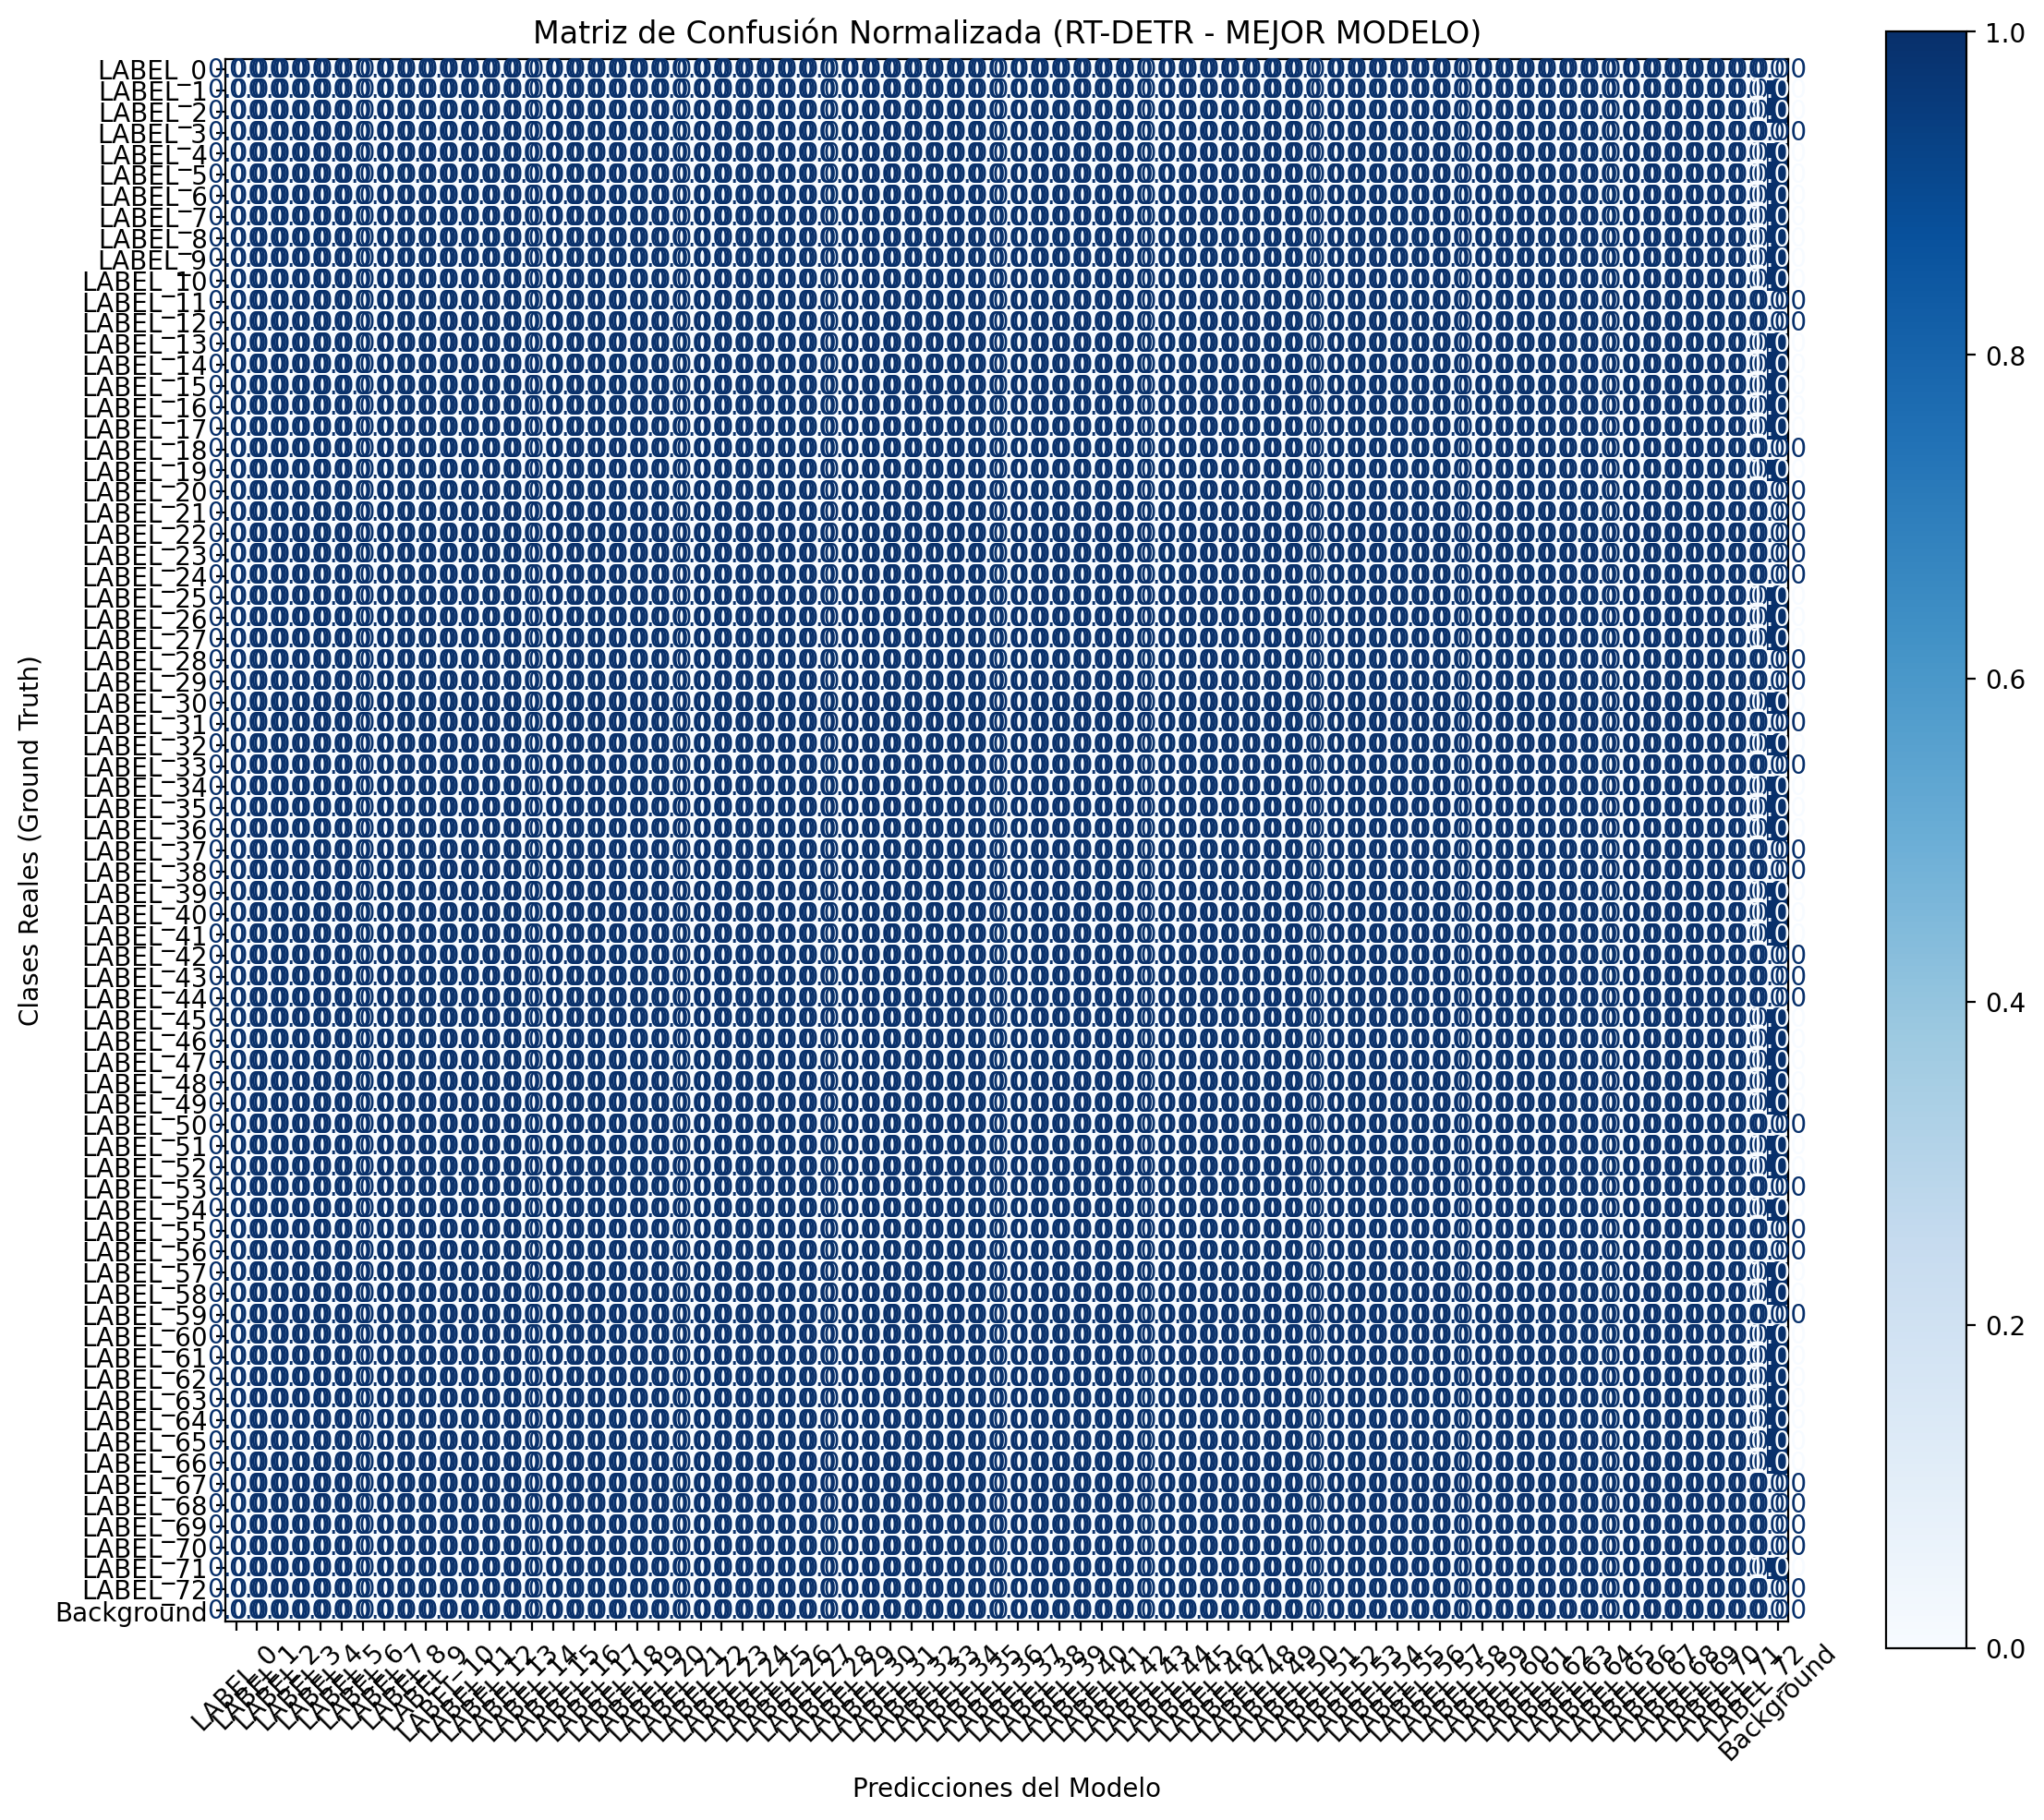

In [32]:
#-------------> ELABORACIÓN DE LA MATRIZ DE CONFUSIÓN NORMALIZADA (VERSION FINAL SIN ERRORES)

import numpy as np
import matplotlib.pyplot as plt
import torch
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ====================================================
# PASO OBLIGATORIO: CARGAR EL MEJOR CHECKPOINT PRIMERO
# ====================================================
checkpoint_path = f"{CHECKPOINT_DIR}/detr_best.pth"

if os.path.exists(checkpoint_path):
    print(f"Cargando el mejor checkpoint desde: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Restauramos los pesos del mejor modelo en la arquitectura actual
    model.load_state_dict(checkpoint["model_state"])
    print(f"-> ¡Éxito! Cargado el modelo de la época {checkpoint['epoch']+1} con pérdida {checkpoint['loss']:.4f}")
else:
    print("¡ALERTA!: No se encontró detr_best.pth. Se evaluará el modelo actual que está en memoria.")

# Enviamos el modelo al dispositivo correcto y activamos modo evaluación
model.to(device)
model.eval()

# 1. CONFIGURACIÓN DE CLASES
id2label = model.config.id2label 
categories = [id2label[i] for i in range(len(id2label))]
categories_with_bg = categories + ["Background"]  # Añadimos el fondo para detecciones fallidas

all_preds = []
all_targets = []

IOU_THRESHOLD = 0.5 

# Extraemos las predicciones usando el mejor modelo cargado
with torch.no_grad():
    for images, targets_raw in val_loader:
        images = [img.to(device) for img in images]
        image_ids = list(range(len(images)))
        targets = convert_coco_batch_for_processor(targets_raw, image_ids)
        
        encoding = processor(images=images, annotations=targets, return_tensors="pt")
        pixel_values = encoding["pixel_values"].to(device)
        
        # CORRECCIÓN 1: Extraer tamaños directamente de las dimensiones de las imágenes
        orig_target_sizes = torch.tensor([img.shape[-2:] for img in images], device=device)
        
        outputs = model(pixel_values=pixel_values)
        
        # CORRECCIÓN 2: Post-procesar todo el lote (sin el [0] del final)
        results = processor.post_process_object_detection(outputs, target_sizes=orig_target_sizes, threshold=0.3)
        
        # CORRECCIÓN 3: Extraer predicciones de cada imagen del lote de forma limpia
        for image_prediction in results:
            for label in image_prediction["labels"]:
                all_preds.append(label.item())
                
        # CORRECCIÓN 4: Extraer etiquetas reales en modo seguro (inspeccionando listas/diccionarios)
        for element in targets_raw:
            if isinstance(element, dict) and 'category_id' in element:
                cat = element['category_id']
                all_targets.append(cat.item() if isinstance(cat, torch.Tensor) else cat)
            elif isinstance(element, list):
                for obj in element:
                    if isinstance(obj, dict) and 'category_id' in obj:
                        cat = obj['category_id']
                        all_targets.append(cat.item() if isinstance(cat, torch.Tensor) else cat)

# Alinear listas por si acaso el modelo predijo más o menos objetos de los reales
max_len = max(len(all_targets), len(all_preds))
if len(all_targets) < max_len:
    all_targets.extend([len(categories)] * (max_len - len(all_targets))) 
if len(all_preds) < max_len:
    all_preds.extend([len(categories)] * (max_len - len(all_preds)))

# 2. CALCULAR LA MATRIZ DE CONFUSIÓN NORMALIZADA
cm = confusion_matrix(all_targets, all_preds, labels=list(range(len(categories_with_bg))), normalize='true')

# 3. PINTAR LA MATRIZ EN PANTALLA
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories_with_bg)

disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45, values_format=".2f")

plt.title("Matriz de Confusión Normalizada (RT-DETR - MEJOR MODELO)")
plt.xlabel("Predicciones del Modelo")
plt.ylabel("Clases Reales (Ground Truth)")
plt.tight_layout()
plt.show()

In [28]:
!pip install scikit-learn matplotlib

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 16.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 16.0 MB/s  0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   ------------------------------ --------- 3/4 [sci